In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [30]:
df.info

<bound method DataFrame.info of         TV  radio  newspaper  sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]>

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### EDA

Text(0.5, 1.0, 'Newspaper Spend')

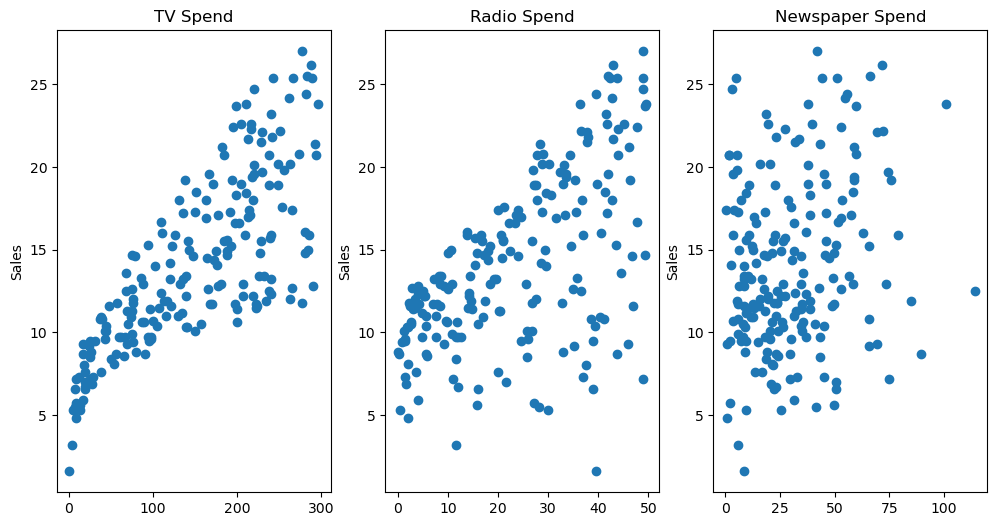

In [32]:
fig, axes= plt.subplots(nrows=1,ncols=3,figsize=(12,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')

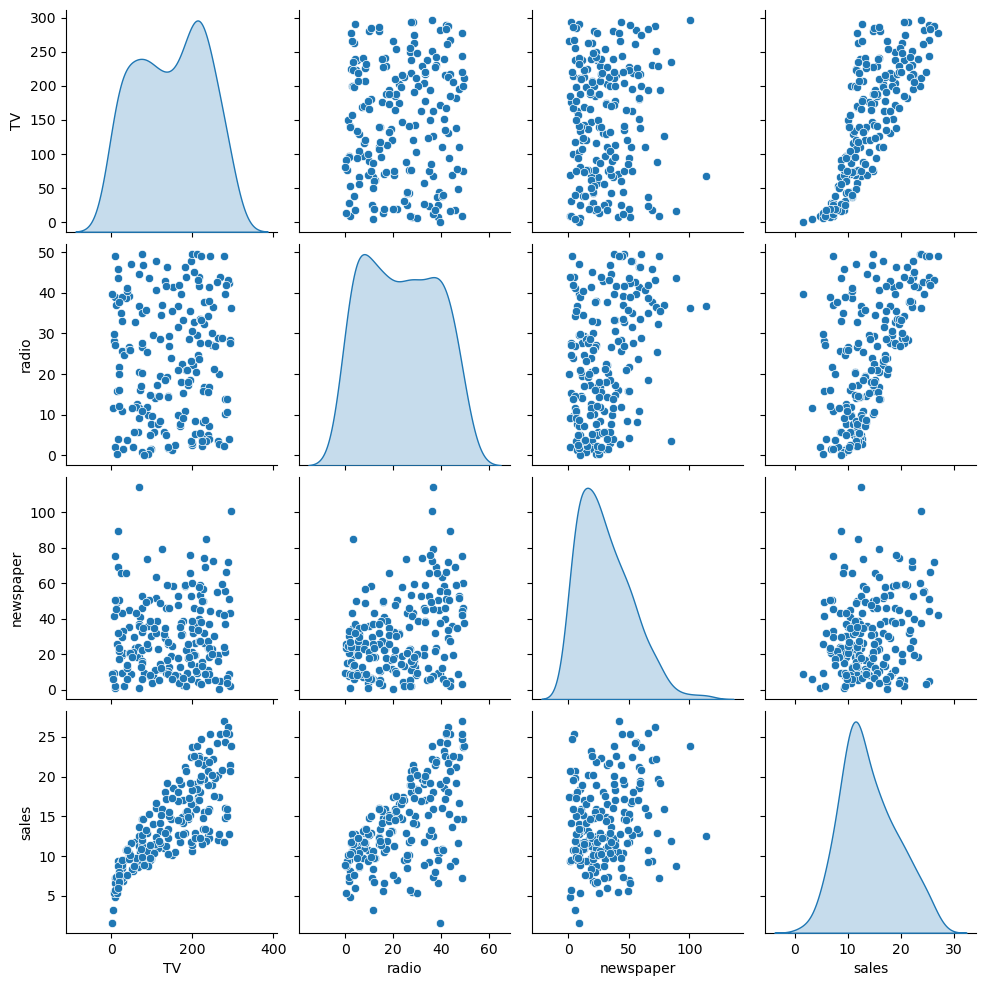

In [33]:
sns.pairplot(df,diag_kind='kde')

In [34]:
X=df.drop('sales',axis=1)
y=df['sales']

In [35]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [36]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

### Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3,random_state=101)

### Creating the model

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lin_reg= LinearRegression()

### Fit/Train the model on the training data

In [41]:
lin_reg.fit(X_train,y_train)

LinearRegression()

In [44]:
test_predictions=lin_reg.predict(X_test)

In [45]:
test_predictions

array([15.74131332, 19.61062568, 11.44888935, 17.00819787,  9.17285676,
        7.01248287, 20.28992463, 17.29953992,  9.77584467, 19.22194224,
       12.40503154, 13.89234998, 13.72541098, 21.28794031, 18.42456638,
        9.98198406, 15.55228966,  7.68913693,  7.55614992, 20.40311209,
        7.79215204, 18.24214098, 24.68631904, 22.82199068,  7.97962085,
       12.65207264, 21.46925937,  8.05228573, 12.42315981, 12.50719678,
       10.77757812, 19.24460093, 10.070269  ,  6.70779999, 17.31492147,
        7.76764327,  9.25393336,  8.27834697, 10.58105585, 10.63591128,
       13.01002595,  9.77192057, 10.21469861,  8.04572042, 11.5671075 ,
       10.08368001,  8.99806574, 16.25388914, 13.23942315, 20.81493419,
       12.49727439, 13.96615898, 17.56285075, 11.14537013, 12.56261468,
        5.50870279, 23.29465134, 12.62409688, 18.77399978, 15.18785675])

In [43]:
y_test

37     14.7
109    19.8
31     11.9
89     16.7
66      9.5
119     6.6
54     20.2
74     17.0
145    10.3
142    20.1
148    10.9
112    14.1
174    11.5
55     23.7
141    19.2
149    10.1
25     12.0
34      9.5
170     8.4
39     21.5
172     7.6
153    19.0
175    27.0
61     24.2
65      9.3
50     11.4
42     20.7
129     9.7
179    12.6
2       9.3
12      9.2
133    19.6
90     11.2
22      5.6
41     17.1
32      9.6
125    10.6
196     9.7
158     7.3
180    10.5
16     12.5
186    10.3
144    11.4
121     7.0
80     11.8
18     11.3
78      5.3
48     14.8
4      12.9
15     22.4
1      10.4
43     12.9
102    14.8
164    11.9
9      10.6
155     3.2
36     25.4
190    10.8
33     17.4
45     14.9
Name: sales, dtype: float64

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [47]:
df['sales'].mean()

np.float64(14.0225)

In [48]:
MAE=mean_absolute_error(y_test,test_predictions)
MAE

1.2137457736144803

In [50]:
1.213745/14.0225 #this will give us approx 9 percent, which is not good, its too much

0.08655696202531646

In [52]:
MSE=mean_squared_error(y_test,test_predictions)
MSE

2.2987166978863782

In [53]:
RMSE= np.sqrt(MSE)
RMSE

np.float64(1.516151937599388)

### Plotting Residuals

In [58]:
test_res= y_test- test_predictions #test residuals

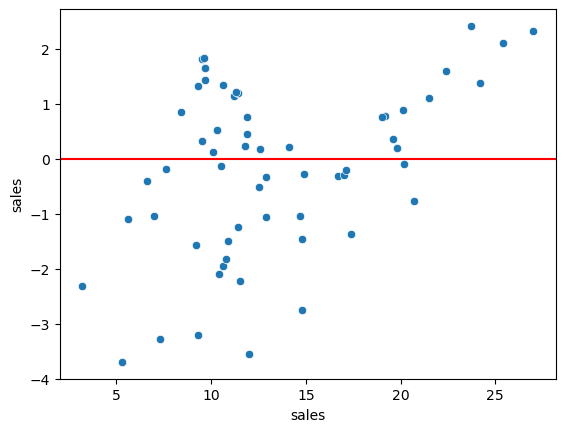

In [56]:
sns.scatterplot(x=y_test,y=test_res)
plt.axhline(y=0,color='red') #gives us a horizontal line

<Axes: xlabel='sales', ylabel='Density'>

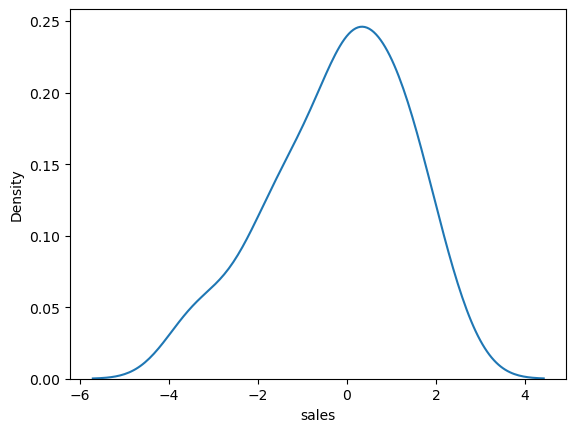

In [57]:
sns.kdeplot(test_res)

### Retrain the model on full data
#### Because we are satisfied with the performance of the test data

In [59]:
final_model=LinearRegression()

In [62]:
final_model.fit(X,y) # here we have fitted to the entire data set

LinearRegression()

In [63]:
y_hat= final_model.predict(X)
y_hat

array([20.52397441, 12.33785482, 12.30767078, 17.59782951, 13.18867186,
       12.47834763, 11.72975995, 12.12295317,  3.72734086, 12.55084872,
        7.0322992 , 17.28512918, 10.57712073,  8.82630048, 18.43436638,
       20.81929952, 12.82365674, 23.22495716,  9.95168206, 14.16607293,
       18.10076728, 14.7405382 ,  6.4891503 , 16.5459329 ,  8.14651887,
       15.6100386 , 14.98951429, 17.05167344, 19.41053803,  9.14402389,
       21.6339338 , 11.3460929 ,  7.63888314, 18.86426829,  7.57483051,
       17.00682618, 23.40590052, 15.62347779,  9.90868103, 20.44761039,
       16.37766467, 17.2959832 , 21.59580326, 13.96385684,  8.88787996,
       15.16152314,  8.87338673, 21.7226299 , 16.26362018,  8.1681656 ,
       12.63121132,  9.33981296, 20.66297563, 19.94469957, 20.37443008,
       21.2926106 ,  8.52771254, 12.77458802, 21.89805198, 18.13348698,
        5.74215558, 22.89067208, 16.78426073, 13.21069202, 16.97773556,
        7.84904532,  9.01603163, 12.0370073 , 18.97657924, 21.10

In [64]:
len(y_hat)

200

Text(0.5, 1.0, 'Newspaper Spend')

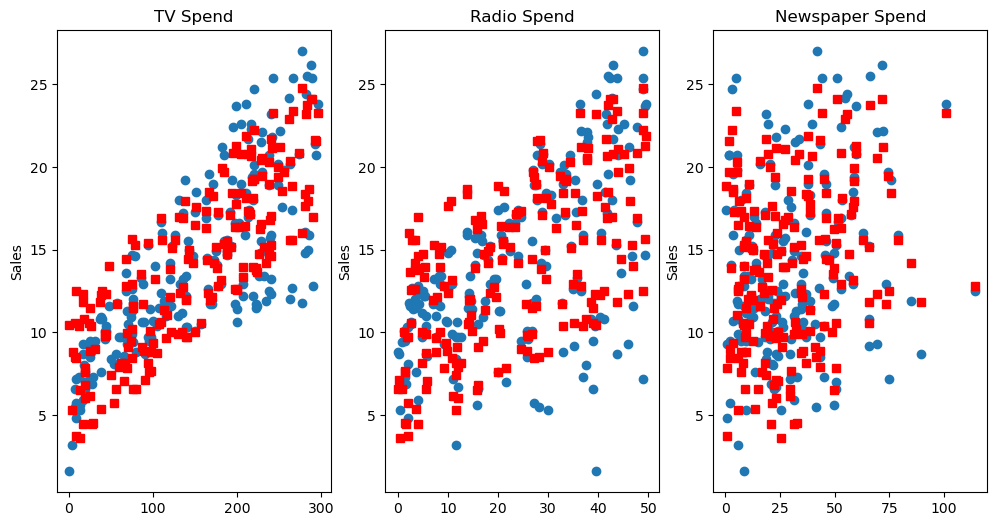

In [67]:
fig, axes= plt.subplots(nrows=1,ncols=3,figsize=(12,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'s',color='red') #blue shows actual and red shows predicted values in graph
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'s',color='red')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Spend')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'s',color='red')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper Spend')

### Residuals

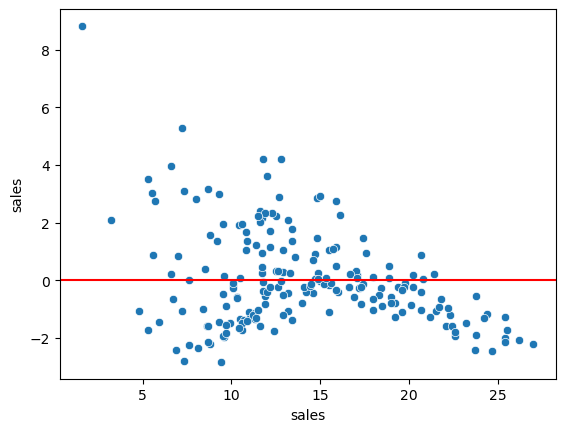

In [68]:
res= y_hat-y

sns.scatterplot(x=y,y=res)
plt.axhline(y=0,color='red') #gives us a horizontal line

### Understanding Coefficients

In [73]:
final_model.coef_ #this will give us coeff for each 3 features(b0,b1,b2: see that b2 is v v small)

array([ 0.04576465,  0.18853002, -0.00103749])

In [72]:
df.head(4)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5


### Predicting on a new data

In [78]:
ad_campaign=[[149,22,12],[45,98,1000],[45,98,5]] #[amount spent on tv,radio,newspaper] in add campaign

In [79]:
final_model.predict(ad_campaign) #this will give us the value of sales for both the input cells

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032  , 22.43674703, 23.46905261])

### Model saving and loading

In [80]:
from joblib import dump,load

In [81]:
dump[final_model,'sales_model.joblib']

TypeError: 'function' object is not subscriptable

In [82]:
dump(final_model,'sales_model.joblib')

['sales_model.joblib']

In [84]:
ad_camp=[[101,78,90],[112,98,34],[121,54,345],[345,436,78]]
loaded_model= load('sales_model.joblib')
loaded_model.predict(ad_camp)

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 22.17308551,  26.50519656,  18.29909728, 100.84585497])